In [39]:
# Step 1: Mount Google Drive to access dataset
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# Step 2: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# For handling imbalanced data
!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE

# Enable inline plots
%matplotlib inline


In [41]:
# Step 3: Load the dataset
file_path = '/content/drive/My Drive/creditcard.csv'  # Update if path is different
df = pd.read_csv(file_path)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [42]:
# Step 4: Check for missing values
print("Missing values in each column:\n", df.isnull().sum())


Missing values in each column:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


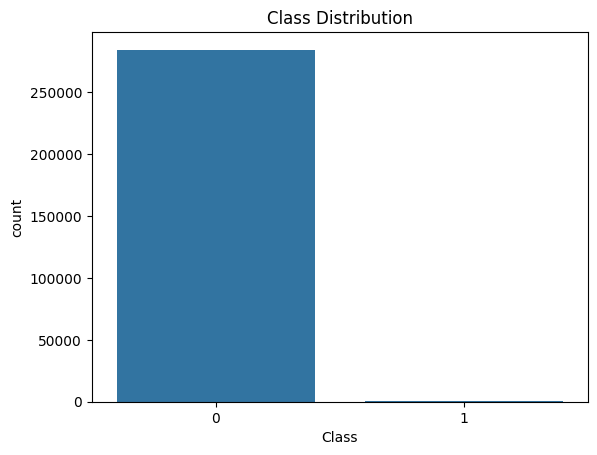

Non-Fraud Transactions: 284315
Fraud Transactions: 492


In [43]:
# Step 5: Show class distribution (fraud vs. non-fraud)
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

print("Non-Fraud Transactions:", (df.Class == 0).sum())
print("Fraud Transactions:", (df.Class == 1).sum())


In [44]:
# Step 6: Split features and labels
X = df.drop(['Class'], axis=1)
y = df['Class']


In [45]:
# Step 7: Split into training and testing sets (with stratification to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [46]:
# Step 8: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [47]:
# Step 9: Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE - Fraud cases:", sum(y_train_smote==1))
print("After SMOTE - Non-Fraud cases:", sum(y_train_smote==0))


After SMOTE - Fraud cases: 227451
After SMOTE - Non-Fraud cases: 227451


In [48]:
# Step 10: Train a Random Forest Classifier on the balanced data
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train_smote, y_train_smote)


RandomForestClassifier(n_estimators=50, random_state=42)

In [49]:
# Step 11: Make predictions on the original test data
y_pred = rf.predict(X_test_scaled)


<ipython-input-50-bb4f802f0d99>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features, y=top_features.index, palette="viridis")


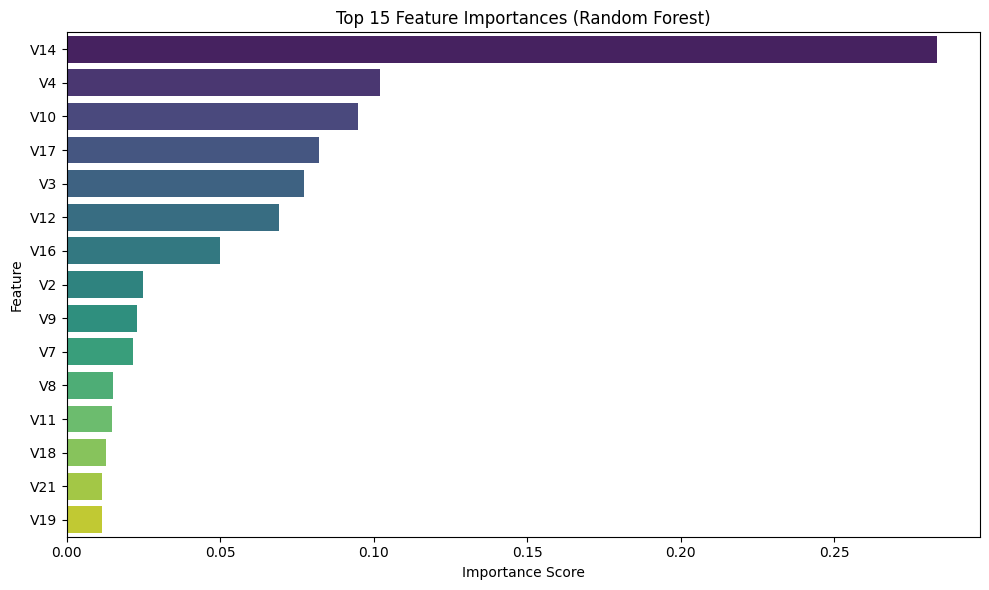

In [50]:
# Step 12: Feature Importance Plot
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_series = pd.Series(importances, index=feature_names)

top_features = feature_importance_series.sort_values(ascending=False)[:15]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features, y=top_features.index, palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Classification Report (Random Forest + SMOTE):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



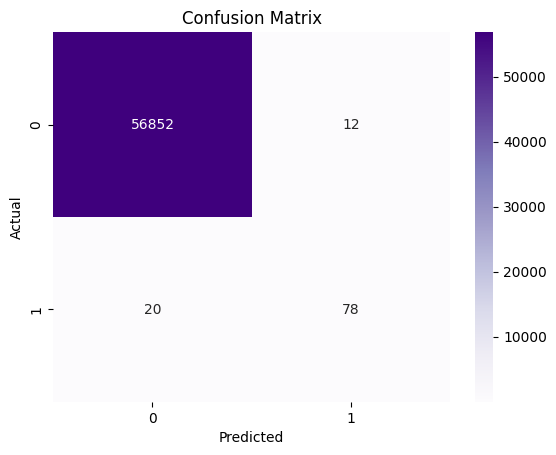

In [51]:
# Step 13: Evaluate the model
print("Classification Report (Random Forest + SMOTE):\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
